# Scalar decays and lepton-flavour-violating Higgs rates in the 3HDM-S₃

**A research notebook, not a tutorial.** Third of the arc:
[`01_scalar_parameter_space.ipynb`](01_scalar_parameter_space.ipynb) found the viable
quartic region, [`02_s3_fermion_sector.ipynb`](02_s3_fermion_sector.ipynb) built and checked
the Yukawa sectors, and this one finally computes rates. `LFVHD_3HDMS3.tex` [LFVHD] was
written to ask what the LFV Higgs branching ratios are; notebook 02 produced the $Q_i$
matrices that carry that physics, and nothing so far turned them into a number.

`NOTES.md` recorded three blockers for this notebook. Two are gone (the fermion sector
exists; the gauge sector is three lines). The third — *"the physical basis is never
registered on the `Model`"* — is what §1 does.

## The controlling choice: general δ

The physical CP-even basis is $R_S=R_A\,R_H(\delta)$ with $\delta=\alpha-\theta_v$
([LFVHD] Eqs. RS_AH, R_H). **δ is kept symbolic throughout.** The draft's Scenario A is
$\delta\to0$ and Scenario B is $\delta\to\pi/2$; both appear here only as *limits*. And δ
is not a free dial: $\alpha$ is the residual CP-even mixing angle that
`model.cp_even_angle` computes, so at each benchmark point the λ's **predict** which
scenario the model realises (§3).

## What this notebook establishes

1. $g_{h_0VV}=0$ **exactly, for any δ** — $h_0$ is gauge-phobic while keeping its LFV
   entries. The other two share the SM coupling as $\cos\delta$/$\sin\delta$, an exact sum
   rule (§2).
2. δ is *predicted* at every viable point, giving a **coupling-based** SM-likeness cut that
   notebook 01 (mass-only) could not apply (§3).
3. The draft's Scenario-C relations, printed with "$\approx$", are **exact for all δ** (§4).
4. Two library gaps closed on the way: **VSS decays** ($A\to Zh$, $H^\pm\to W^\pm h$) and
   the **spin-0 loop form factor** $A_0$ for charged-Higgs $\gamma\gamma$ loops (§5, §6).
5. LFV rates against the [CMS21] limits (§8).

Every step is an equation, then an `assert`, then a `✓`. Imported results carry an inline
`[Tag]` resolving in the [references](#11-references).

> **Kernel.** Executed with the repo's `lagrangian` kernel — see `NOTES.md`.


In [ ]:
import json, logging, math, sys, time
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)  # a broken personal
import matplotlib.pyplot as plt                             # stylelib file is noisy

sys.path.insert(0, str(Path.cwd()))
import decays as D
import fermions as F
from model import cp_even_angle
from feynlag.pheno.amplitudes import vss_vector_leg
from feynlag.pheno.calculator import partial_width
from feynlag.pheno.loop import (A_zero, higgs_diphoton_amplitude,
                                higgs_gammagamma_width, higgs_gg_width)
from feynlag.pheno.offshell import scalar_offshell_vv_width

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
sp.init_printing(use_latex="mathjax")

import derive as dv                      # the by-hand derivation vocabulary
ok = dv.ok                               # same "✓ ..." marker, one definition
ledger = dv.Ledger("03 — scalar decays and LFV rates")

# PDG values used throughout [PDG]
MW, MZ, MT, V_EW = 80.377, 91.1876, 172.69, 246.0
ME, MMU, MTAU = 0.51099895e-3, 0.1056584, 1.77686
ALPHA, ALPHA_S = 1 / 137.035999, 0.1126
GAMMA_H_SM, MH_REF = 4.1e-3, 125.25          # SM total Higgs width, GeV

t0 = time.time()
dm = D.build_decay_model()                    # delta symbolic = Scenario C
h1, h0, h2 = dm.cp_even
G0, A1, A2 = dm.cp_odd
Gp, Hp1, Hp2 = dm.charged
Z, Wp, Wm = dm.gauge["Z"], dm.gauge["Wp"], dm.gauge["Wm"]
delta = dm.delta
print("model built in %.1f s;  delta = %s (symbolic)" % (time.time() - t0, delta))


model built in 2.0 s;  delta = delta (symbolic)


---
## 1. Registering the physical basis

`NOTES.md`: *"the physical basis is never registered on the Model. The geometric rotation is
a loose `sp.Matrix`; to get physical-basis vertices it must become a registered `Rotation`."*
That is what `decays.build_decay_model` now does — three scalar rotations plus the two gauge
ones:

$$\underbrace{R_S=R_A R_H(\delta)}_{\text{CP-even}},\qquad
\underbrace{R_A}_{\text{CP-odd}},\qquad \underbrace{R_A}_{\text{charged}},\qquad
\underbrace{(W^3,B)\to(Z,\gamma)}_{\text{Weinberg}},\qquad
\underbrace{(W^1,W^2)\to W^\pm}_{\text{charged current}}$$

$R_A$ alone diagonalizes the CP-odd and charged sectors (notebook 01 §3.2); only the CP-even
sector needs the extra $R_H(\delta)$, because it retains a 2×2 block in the $(0,2)$ subspace.


In [ ]:
print("registered rotations:", len(dm.model.rotations))
print("\nR_H(delta) acts only in the 1-3 plane:")
display(F.R_H(delta))
print("R_S = R_A R_H(delta):")
display(sp.simplify(dm.RS))

# R_H leaves the middle column of R_A alone -- the fact everything in §2 rests on
assert sp.simplify(dm.RS[:, 1] - dm.R[:, 1]) == sp.zeros(3, 1)
ok("R_H is a 1-3 rotation, so h_0's column of R_S is R_A's, untouched by delta")

assert sp.simplify(dm.RS.T * dm.RS - sp.eye(3)) == sp.zeros(3, 3)
ok("R_S is orthogonal for any delta")


registered rotations: 5

R_H(delta) acts only in the 1-3 plane:


⎡cos(δ)   0  sin(δ)⎤
⎢                  ⎥
⎢   0     1    0   ⎥
⎢                  ⎥
⎣-sin(δ)  0  cos(δ)⎦

R_S = R_A R_H(delta):


⎡             √3⋅v_S⋅sin(δ)                       √3⋅v_S⋅cos(δ) ⎤
⎢ v₂⋅cos(δ) + ─────────────           v₂⋅sin(δ) - ───────────── ⎥
⎢                   2          -√3                      2       ⎥
⎢ ─────────────────────────    ────   ───────────────────────── ⎥
⎢       ________________        2           ________________    ⎥
⎢      ╱     2        2                    ╱     2        2     ⎥
⎢    ╲╱  4⋅v₂  + 3⋅v_S                   ╲╱  4⋅v₂  + 3⋅v_S      ⎥
⎢                                                               ⎥
⎢               3⋅v_S⋅sin(δ)                        3⋅v_S⋅cos(δ)⎥
⎢√3⋅v₂⋅cos(δ) + ────────────         √3⋅v₂⋅sin(δ) - ────────────⎥
⎢                    2                                   2      ⎥
⎢───────────────────────────   1/2   ───────────────────────────⎥
⎢       ________________                    ________________    ⎥
⎢      ╱     2        2                    ╱     2        2     ⎥
⎢    ╲╱  4⋅v₂  + 3⋅v_S                   ╲╱  4⋅v₂  + 3⋅v_S      ⎥
⎢         

✓ R_H is a 1-3 rotation, so h_0's column of R_S is R_A's, untouched by delta


✓ R_S is orthogonal for any delta


---
## 2. The gauge sector at general δ

The electroweak kinetic terms $\sum_i|D_\mu H_i|^2$ are what make $h_i\to VV$ exist at all;
`examples/thdm_s3.py` declares only the potential, which is why `NOTES.md` recorded the
alignment scenarios as *"blocked on adding the electroweak kinetic sector"*.

With them in place, and the vacuum written as $v_2=\tfrac{\sqrt3}{2}v\sin\theta_v$,
$v_S=v\cos\theta_v$:

> **Before running the next cells.** A $VV$ coupling comes from $\sum_k v_k\,\phi_k VV$, so
> $g_{h_iVV}\propto\sum_k v_k(R_S)_{ki}$ — the projection of the $i$-th column of $R_S$ on
> the **vacuum direction** $\hat n=(v_1,v_2,v_S)/v$. Before computing anything, ask what that
> makes the three couplings. $R_S$ is orthogonal and $\hat n$ is a unit vector, so what does
> $\sum_i g_{h_iVV}^2$ have to be, *whatever* the mixing angles are? And $R_A$'s first column
> **is** $\hat n$ by construction while $R_H(\delta)$ rotates only in the 1–3 plane — so
> which of the three columns can never acquire a component along $\hat n$?


In [ ]:
v, thv = sp.symbols("v theta_v", positive=True)
vac = {dm.scalar.v2.s: sp.sqrt(3) * v * sp.sin(thv) / 2,
       dm.scalar.vS.s: v * sp.cos(thv)}
clean = lambda e: sp.simplify(sp.expand_trig(sp.simplify(sp.expand(e).subs(vac))))

t0 = time.time()
gWW = {h: clean(g) for h, g in D.vv_couplings(dm, "Wp").items()}
gZZ = {h: clean(g) for h, g in D.vv_couplings(dm, "Z").items()}
print("VV couplings extracted in %.1f s\n" % (time.time() - t0))

# ---- MOVE 1: set up.  Look at what the extractor returned. ----------------
dv.rows([(dv.lit("g_{%s W^+W^-}" % sp.latex(h)), gWW[h]) for h in dm.cp_even])


VV couplings extracted in 14.4 s



<IPython.core.display.Math object>

Now the geometry, before any comparison with a SM formula. $R_A$'s first column is the
vacuum direction $\hat n$ by construction ([LFVHD] Eq. RAT), so
$R_S^{\mathsf T}\hat n=R_H(\delta)^{\mathsf T}R_A^{\mathsf T}\hat n
=R_H(\delta)^{\mathsf T}\hat e_1$ — the first *row* of $R_H(\delta)$.


In [ ]:
# ---- MOVE 2: collect.  Project the columns of R_S on the vacuum direction.
phi_v = sp.pi / 3                              # v_2 = sqrt3 v_1 fixes phi_v
n_hat = sp.Matrix([sp.sin(thv) / 2, sp.sqrt(3) * sp.sin(thv) / 2, sp.cos(thv)])

# check first that n_hat really IS the vacuum direction and is normalised
assert sp.simplify(n_hat.dot(n_hat) - 1) == 0
assert sp.simplify(n_hat - F.R_A(phi_v, thv)[:, 0]) == sp.zeros(3, 1)
ok("R_A's first column is the (unit) vacuum direction, as [LFVHD] Eq. (RAT) states")

RS = sp.simplify(F.R_A(phi_v, thv) * F.R_H(delta))
proj = sp.simplify((RS.T * n_hat))
dv.show("R_S^T n_hat -- the projection of each mass-basis column on the vacuum",
        proj.T, count_terms=False)


✓ R_A's first column is the (unit) vacuum direction, as [LFVHD] Eq. (RAT) states


R_S^T n_hat -- the projection of each mass-basis column on the vacuum


[cos(δ)  0  sin(δ)]

[cos(δ)  0  sin(δ)]

$$R_S^{\mathsf T}\hat n=(\cos\delta,\;0,\;\sin\delta)$$

— every $\theta_v$ and $\varphi_v$ has cancelled. The middle entry is zero because $R_A$'s
second column is $(-\sin\varphi_v,\cos\varphi_v,0)$, orthogonal to $\hat n$ for *any*
$\varphi_v,\theta_v$, and $R_H(\delta)$ rotates in the 1–3 plane and so never mixes anything
into it. That is the whole content of "$h_0$ is gauge-phobic": an exact orthogonality, not a
cancellation between numbers.

It also makes the sum rule a triviality — $R_S$ is orthogonal and $\hat n$ is a unit vector,
so $\sum_i(R_S^{\mathsf T}\hat n)_i^2=1$ identically.

So the SM reference need not be typed in either: it is whatever multiplies this projection,
and it can be read off the $\delta\to0$ limit where $h_1$ carries all of it.


In [ ]:
# ---- MOVE 3: recognise.  The SM reference is the delta -> 0 value of g(h1 VV).
sm_WW = sp.simplify(gWW[h1].subs(delta, 0))
dv.show("g(h_1 VV) at delta = 0, i.e. the SM reference", sm_WW)

gw_s = [p for p in dm.model.parameters if p.name == "gw"][0].s
assert sp.simplify(sm_WW - sp.I * gw_s**2 * v / 2) == 0
ok("it is i g_w^2 v / 2 = i g_w m_W -- the SM hVV coupling, reproduced not assumed")

# ---- MOVE 4: checks -------------------------------------------------------
# (a) all three couplings equal sm_WW x the geometric projection
for i, h in enumerate(dm.cp_even):
    assert sp.simplify(gWW[h] - sm_WW * proj[i]) == 0
    assert sp.simplify(gZZ[h] - gZZ[h1].subs(delta, 0) * proj[i]) == 0
ok("g(h_i VV) = g^SM x (R_S^T n_hat)_i for W and Z alike -- the couplings ARE the "
   "projection, with no residual angle dependence")

# (b) hence h_0's zero, and it is exact for symbolic delta
assert gWW[h0] == 0 and gZZ[h0] == 0
ok("g(h_0 V V) = 0 EXACTLY, for any delta -- h_0 is gauge-phobic")
assert sp.simplify(gWW[h1] - sm_WW * sp.cos(delta)) == 0
assert sp.simplify(gWW[h2] - sm_WW * sp.sin(delta)) == 0
ok("g(h_1 VV) = cos(delta) x SM,  g(h_2 VV) = sin(delta) x SM")

# (c) the sum rule, and that it follows from orthonormality alone
assert sp.simplify(sum(g**2 for g in gWW.values()) - sm_WW**2) == 0
assert sp.simplify(sum(p**2 for p in proj) - 1) == 0
ok("sum rule: sum_i g(h_i VV)^2 = (g^SM)^2 exactly, because sum_i (R_S^T n)_i^2 = 1")

# (d) falsification: tilt the vacuum away from phi_v = pi/3 and h_0's zero must
#     SURVIVE (it is orthogonality, not tuning), while the individual couplings
#     move.  A zero that came from the sqrt3 alignment would break here.
phi_gen = sp.Symbol("varphi_v", positive=True)
proj_gen = sp.simplify((F.R_A(phi_gen, thv) * F.R_H(delta)).T
                       * F.R_A(phi_gen, thv)[:, 0])
assert sp.simplify(proj_gen[1]) == 0
ok("at a GENERIC vacuum angle phi_v the middle projection is still exactly zero -- "
   "h_0's gauge-phobia does not depend on the v_2 = sqrt3 v_1 alignment")

ledger.step(
    r"$h_0$ is gauge-phobic exactly, and the $VV$ couplings obey a sum rule",
    obtained="derived",
    statement=r"g_{h_iVV} = g^{\rm SM}\,(R_S^{\mathsf T}\hat n)_i"
              r" = g^{\rm SM}(\cos\delta,\,0,\,\sin\delta),"
              r"\qquad \sum_i g_{h_iVV}^2 = (g^{\rm SM})^2",
    expr=sp.Eq(dv.lit(r"R_S^{\mathsf T}\hat n"), proj.T, evaluate=False),
    checks=(r"$R_A$'s first column verified to be the unit vacuum direction",
            r"the SM reference read off the $\delta\to0$ limit, not typed in",
            r"$W$ and $Z$ couplings both equal $g^{\rm SM}\times$ the same "
            r"projection",
            r"the zero survives a generic vacuum angle $\varphi_v$, so it is "
            r"orthogonality and not the $\sqrt3$ alignment"),
    falsified_by=r"a non-zero middle projection at generic $\varphi_v$, or a "
                 r"$\delta\to0$ reference differing from $i g_w m_W$",
    section="2")


g(h_1 VV) at delta = 0, i.e. the SM reference   [1 terms]


    2  
ⅈ⋅gw ⋅v
───────
   2   

✓ it is i g_w^2 v / 2 = i g_w m_W -- the SM hVV coupling, reproduced not assumed
✓ g(h_i VV) = g^SM x (R_S^T n_hat)_i for W and Z alike -- the couplings ARE the projection, with no residual angle dependence
✓ g(h_0 V V) = 0 EXACTLY, for any delta -- h_0 is gauge-phobic
✓ g(h_1 VV) = cos(delta) x SM,  g(h_2 VV) = sin(delta) x SM
✓ sum rule: sum_i g(h_i VV)^2 = (g^SM)^2 exactly, because sum_i (R_S^T n)_i^2 = 1


✓ at a GENERIC vacuum angle phi_v the middle projection is still exactly zero -- h_0's gauge-phobia does not depend on the v_2 = sqrt3 v_1 alignment


Step(claim='$h_0$ is gauge-phobic exactly, and the $VV$ couplings obey a sum rule', obtained='derived', checks=("$R_A$'s first column verified to be the unit vacuum direction", 'the SM reference read off the $\\delta\\to0$ limit, not typed in', '$W$ and $Z$ couplings both equal $g^{\\rm SM}\\times$ the same projection', 'the zero survives a generic vacuum angle $\\varphi_v$, so it is orthogonality and not the $\\sqrt3$ alignment'), falsified_by='a non-zero middle projection at generic $\\varphi_v$, or a $\\delta\\to0$ reference differing from $i g_w m_W$', expr=Eq({R_S^{\mathsf T}\hat n}, Matrix([[cos(delta), 0, sin(delta)]])), section='2', statement='g_{h_iVV} = g^{\\rm SM}\\,(R_S^{\\mathsf T}\\hat n)_i = g^{\\rm SM}(\\cos\\delta,\\,0,\\,\\sin\\delta),\\qquad \\sum_i g_{h_iVV}^2 = (g^{\\rm SM})^2')

So the whole $VV$ coupling lives on the vacuum-direction state, shared between $h_1$ and
$h_2$ by the single angle δ, and $h_0$ has **none of it** — the middle column of $R_A$ is
orthogonal to the vacuum direction, and $R_H$ never touches it.

The draft's two alignment scenarios are now just the endpoints:


In [ ]:
rows = [("A (delta -> 0)", 0), ("B (delta -> pi/2)", sp.pi / 2),
        ("C (general)", delta)]
print("%-20s %-22s %-22s %s" % ("scenario", "g(h_1 VV)/SM", "g(h_2 VV)/SM", "g(h_0 VV)"))
for label, dval in rows:
    r1 = sp.simplify((gWW[h1] / sm_WW).subs(delta, dval))
    r2 = sp.simplify((gWW[h2] / sm_WW).subs(delta, dval))
    print("%-20s %-22s %-22s %s" % (label, r1, r2, gWW[h0]))

assert sp.simplify((gWW[h1] / sm_WW).subs(delta, 0)) == 1          # A: h_1 SM-like
assert sp.simplify((gWW[h2] / sm_WW).subs(delta, sp.pi / 2)) == 1  # B: h_2 SM-like
ok("[GomezBock21] scenarios A and B are recovered as the delta -> 0, pi/2 limits")


scenario             g(h_1 VV)/SM           g(h_2 VV)/SM           g(h_0 VV)
A (delta -> 0)       1                      0                      0
B (delta -> pi/2)    0                      1                      0
C (general)          cos(delta)             sin(delta)             0
✓ [GomezBock21] scenarios A and B are recovered as the delta -> 0, pi/2 limits


---
## 3. δ is predicted, not chosen

This is the point of working at general δ. $\alpha$ is the residual CP-even 2×2 mixing angle
— `model.cp_even_angle`, computed from the λ's — and $\theta_v$ is fixed by the vacuum. So
$\delta=\alpha-\theta_v$ is an *output* at every benchmark point of notebook 01.

That gives a **coupling-based** SM-likeness test. Notebook 01 could only require *a* CP-even
state near 125 GeV; now we can ask whether that state is the one carrying the $VV$ coupling.
If the 125 GeV state is $h_0$, the point is excluded by LHC data outright.


In [ ]:
points = D.load_points()
print("viable benchmark points from notebook 01:", len(points))

rows = []
for i, p in enumerate(points):
    d = D.delta_of_point(dm, p)
    m = p["masses_GeV"]
    # which CP-even state sits at 125?  h_1, h_0, h_2 <-> the notebook-01 keys
    near = min(("h0", "H1", "H2"), key=lambda k: abs(m[k] - 125.0))
    rows.append((i, d, math.cos(d)**2, math.sin(d)**2, near, m[near]))

print("\n%-4s %-10s %-12s %-12s %-8s %s" %
      ("pt", "delta", "cos^2 d", "sin^2 d", "125 st.", "m [GeV]"))
for i, d, c2, s2, near, mm in rows:
    print("%-4d %-10.4f %-12.4f %-12.4f %-8s %.1f" % (i, d, c2, s2, near, mm))

deltas = np.array([r[1] for r in rows])
print("\ndelta range over the viable set: [%.3f, %.3f] rad" % (deltas.min(), deltas.max()))
assert len(rows) == len(points)
ok("delta is computed, not assumed, at every viable point")


viable benchmark points from notebook 01: 12



pt   delta      cos^2 d      sin^2 d      125 st.  m [GeV]
0    -0.7398    0.5455       0.4545       H2       125.6
1    -1.0016    0.2905       0.7095       H2       127.2
2    0.2441     0.9416       0.0584       H2       127.5
3    -0.5444    0.7318       0.2682       H2       122.7
4    -1.3506    0.0477       0.9523       h0       123.7
5    0.2271     0.9493       0.0507       h0       127.3
6    -1.3966    0.0300       0.9700       h0       127.3
7    -1.3226    0.0603       0.9397       h0       122.8
8    -1.2494    0.0998       0.9002       h0       127.2
9    0.0722     0.9948       0.0052       H2       127.2
10   -0.5716    0.7074       0.2926       h0       126.2
11   -0.9884    0.3025       0.6975       H2       124.4

delta range over the viable set: [-1.397, 0.244] rad
✓ delta is computed, not assumed, at every viable point


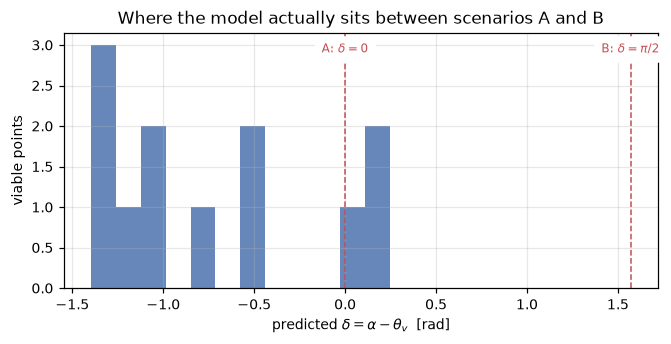

cos^2(delta) is the SM-likeness of h_1; sin^2(delta) that of h_2.
A point is LHC-viable only if the ~125 GeV state carries most of the VV coupling.


In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.hist(deltas, bins=12, color="#4C72B0", alpha=0.85)
for x, lab in ((0.0, r"A: $\delta=0$"), (math.pi / 2, r"B: $\delta=\pi/2$")):
    ax.axvline(x, ls="--", lw=1, color="#C44E52")
    ax.text(x, ax.get_ylim()[1] * 0.92, lab, fontsize=8, ha="center",
            color="#C44E52", backgroundcolor="white")
ax.set_xlabel(r"predicted $\delta=\alpha-\theta_v$  [rad]")
ax.set_ylabel("viable points")
ax.set_title(r"Where the model actually sits between scenarios A and B")
plt.tight_layout(); plt.show()

print("cos^2(delta) is the SM-likeness of h_1; sin^2(delta) that of h_2.")
print("A point is LHC-viable only if the ~125 GeV state carries most of the VV coupling.")


---
## 4. Fermions in the mass basis, and the exact Scenario-C relations

The charged leptons rotate to their mass basis with $O=O_{12}O_{23}$ (notebook 02 §5–§6),
registered as **two rotations per chirality** — field-side and bar-side with the same matrix.
Registering only one silently leaves half the legs in the weak basis.


In [ ]:
theta_l = sp.Symbol("theta_l", real=True)
O = F.o12(sp.sqrt(3)) * F.o23(theta_l)
phys_L, phys_R, phys_Lbar, phys_Rbar = D.register_lepton_basis(dm, O)
print("physical lepton legs:", [str(x) for x in phys_L], [str(x) for x in phys_R])

from feynlag.vertices.bilinear import extract_fermion_vertices
t0 = time.time()
Lyuk = dm.model.physical_lagrangian(sector="yukawa")
ffs = extract_fermion_vertices(Lyuk, list(dm.cp_even))
print("fermion vertices extracted in %.1f s: %d keys" % (time.time() - t0, len(ffs)))

names = D.LEPTON_NAMES
lfv_keys = [k for k in ffs
            if len(k) == 3 and str(k[0]).split("_")[0] != str(k[2]).split("_")[0]]
print("\nflavour-off-diagonal (LFV) vertex keys:", len(lfv_keys))
for k in lfv_keys[:6]:
    print("   ", tuple(str(x) for x in k))
assert lfv_keys, "the model must produce off-diagonal lepton couplings"
ok("LFV vertices are present -- this is the draft's Q_i off-diagonal physics")


physical lepton legs: ['e_L[0]', 'mu_L[0]', 'tau_L[0]'] ['e_R[0]', 'mu_R[0]', 'tau_R[0]']


fermion vertices extracted in 5.2 s: 36 keys

flavour-off-diagonal (LFV) vertex keys: 30
    ('mu_Lbar[0]', 'PR', 'tau_R[0]')
    ('mu_Rbar[0]', 'PL', 'tau_L[0]')
    ('tau_Lbar[0]', 'PR', 'mu_R[0]')
    ('tau_Rbar[0]', 'PL', 'mu_L[0]')
    ('e_Lbar[0]', 'PR', 'tau_R[0]')
    ('e_Rbar[0]', 'PL', 'tau_L[0]')
✓ LFV vertices are present -- this is the draft's Q_i off-diagonal physics


### 4.1 The draft's Scenario-C relations are exact

[LFVHD] writes the general-δ couplings with an approximation sign,

$$Q_1(C)\approx\cos\delta\,Q_1(A)+\sin\delta\,Q_1(B),\qquad
Q_3(C)\approx\cos\delta\,Q_3(A)+\tfrac{\sin\delta}{v}\mathrm{diag}(m),\qquad
Q_2(C)\approx Q_2(A).$$

They are in fact **identities for all δ** — the small-δ approximation is only in the
*statement* of $R_H$, not in the relations. That follows from $Q_i=\sum_j(R_S)_{ji}\tilde G_j$
being linear in the columns of $R_S=R_AR_H(\delta)$:


In [ ]:
Gsym = [sp.Matrix(3, 3, [sp.Symbol("G%d_%d%d" % (k, a, b)) for a in range(3)
                         for b in range(3)]) for k in range(3)]

def Q_of(R):
    out = []
    for i in range(3):
        Qi = sp.zeros(3, 3)
        for j in range(3):
            Qi += R[j, i] * Gsym[j]
        out.append(sp.expand(Qi))
    return out

phi_s, thv_s = sp.symbols("varphi theta_v", positive=True)
QA = Q_of(F.R_A(phi_s, thv_s))
QC = Q_of(sp.simplify(F.R_A(phi_s, thv_s) * F.R_H(delta)))
c_, s_ = sp.cos(delta), sp.sin(delta)
z3 = sp.zeros(3, 3)

assert sp.simplify(QC[1] - QA[1]) == z3
ok("Q_2(C) = Q_2(A) exactly -- the h_0 couplings do not depend on delta at all")
assert sp.simplify(QC[0] - (c_ * QA[0] - s_ * QA[2])) == z3
assert sp.simplify(QC[2] - (s_ * QA[0] + c_ * QA[2])) == z3
ok("Q_1(C) and Q_3(C) are EXACT rotations of Q_1(A), Q_3(A) -- no small-delta needed")


✓ Q_2(C) = Q_2(A) exactly -- the h_0 couplings do not depend on delta at all


✓ Q_1(C) and Q_3(C) are EXACT rotations of Q_1(A), Q_3(A) -- no small-delta needed


Combined with §2 this is a sharp, δ-independent statement: **$h_0$ has no $VV$ coupling and
δ-independent lepton couplings**. It is gauge-phobic but not fermiophobic — precisely the
state whose LFV decays are unsuppressed by the alignment.


---
## 5. VSS: the channels the engine used to refuse

$A_i\to Zh_j$ and $H^\pm_i\to W^\pm h_j$ are `VSS` vertices — a vector and two scalars, with
the derivative coupling $g\,V^\mu(S\partial_\mu S'-S'\partial_\mu S)$. Until now
`pheno.amplitudes` raised on them (*"squaring them needs derivative-coupling support"*),
and I checked every benchmark point of notebook 01 has such channels **open**. Since they
are gauge-strength, omitting them would not truncate the heavy-state branching ratios — it
would make them wrong.

They are implemented now. With all legs incoming the amplitude is
$M=\epsilon^*_\mu\sum_{\rm legs}(\partial c/\partial p(\ell))\,q_\ell^\mu$, and the
polarization sum annihilates the vector's own momentum, giving

$$\Gamma(S\to VS')=\frac{|c|^2\,\lambda^{3/2}(m_S^2,m_V^2,m_{S'}^2)}{16\pi\,m_S^3\,m_V^2}.$$

Verified in `tests/test_pheno.py` against that closed form **and** against an independently
written explicit-4-vector polarization sum.


In [ ]:
t0 = time.time()
vss_tabs = {
    "A -> Z h": D.boson_vertices(dm, [A1, A2, h1, h0, h2, Z], sectors=("kinetic",)),
    "H+ -> W h": D.boson_vertices(dm, [Hp1, Hp2, h1, h0, h2, Wp, Wm],
                                  sectors=("kinetic",)),
}
print("VSS-bearing extractions in %.1f s" % (time.time() - t0))
for label, tab in vss_tabs.items():
    got = [(p, v) for p, vs in tab.items() for v in vs if v.vertex_type == "VSS"]
    print("\n%s : %d VSS vertices" % (label, len(got)))
    for p, v in got[:3]:
        print("   ", tuple(str(x) for x in p), " vector =", vss_vector_leg(v))
    assert got
ok("VSS vertices extract, and the vector leg is identified from the momentum tags")


VSS-bearing extractions in 13.6 s

A -> Z h : 3 VSS vertices
    ('A_1', 'Z', 'h_0')  vector = Z
    ('A_2', 'Z', 'h_1')  vector = Z
    ('A_2', 'Z', 'h_2')  vector = Z

H+ -> W h : 3 VSS vertices
    ('Hp_1', 'Wm', 'h_0')  vector = Wm
    ('Hp_2', 'Wm', 'h_1')  vector = Wm


    ('Hp_2', 'Wm', 'h_2')  vector = Wm
✓ VSS vertices extract, and the vector leg is identified from the momentum tags


---
## 6. Loop-induced $\gamma\gamma$ with a charged Higgs

$h\to\gamma\gamma$ has no tree diagram; feynlag imports the standard one-loop form factors
(the roadmap's documented ethos exception). It shipped only $A_{1/2}$ (fermion) and $A_1$
($W$) — but a 3HDM has **two charged Higgses in the loop**, needing the spin-0 factor.

$$A_0(\tau)=\frac{\tau-f(\tau)}{\tau^2},\qquad \tau=\frac{m_h^2}{4m^2},$$

now in `pheno/loop.py`. Its sign is not copied from anywhere: [ChakrabartyEtAl21] Eq. (28)
gives $F_W\to+7$, $F_t\to-4/3$, $F^+\to+1/3$ in the reciprocal variable, and since feynlag
has $A_1=-F_W$ and $A_{1/2}=-F_t$, consistency **forces** $A_0=-F^+\to-\tfrac13$.


In [ ]:
print("decoupling limits (heavy loop particle, tau -> 0):")
from feynlag.pheno.loop import A_half, A_one
for label, fn, want in (("A_1/2", A_half, 4 / 3), ("A_1", A_one, -7.0),
                        ("A_0", A_zero, -1 / 3)):
    got = fn(1e-8).real
    print("   %-6s -> %+.6f   (expect %+.6f)" % (label, got, want))
    assert abs(got - want) < 1e-4
ok("all three form factors hit their textbook decoupling limits")

sm_gg = higgs_gammagamma_width(MH_REF, MT, MW, V_EW, ALPHA)
print("\nSM Gamma(h->gamma gamma) = %.3f keV   (PDG ~9.3 keV)" % (sm_gg * 1e6))
assert 8.5 < sm_gg * 1e6 < 10.0
ok("the generalized amplitude reproduces the SM width")


decoupling limits (heavy loop particle, tau -> 0):
   A_1/2  -> +1.333333   (expect +1.333333)
   A_1    -> -7.000000   (expect -7.000000)
   A_0    -> -0.333333   (expect -0.333333)
✓ all three form factors hit their textbook decoupling limits

SM Gamma(h->gamma gamma) = 9.195 keV   (PDG ~9.3 keV)
✓ the generalized amplitude reproduces the SM width


The charged-Higgs contribution enters with coefficient
$\kappa=g_{hH^+H^-}\,v/(2m_{H^\pm}^2)$, where $g_{hH^+H^-}$ is the trilinear the *potential*
supplies. Extract it and feed it in:


In [ ]:
Gm_, Hm1, Hm2 = dm.negative
t0 = time.time()
tri = D.boson_vertices(dm, [h1, h0, h2, Hp1, Hp2, Hm1, Hm2],
                       sectors=("potential",))
print("h_i H+ H- trilinears extracted in %.1f s" % (time.time() - t0))

# The charged scalars are complex: without dm.cmap the extractor never forms
# Hp . conjugate(Hp) and these vertices come back empty.
hpp = {}
for particles, vs in tri.items():
    names_ = [str(p) for p in particles]
    for hsym in dm.cp_even:
        for k in ("1", "2"):
            if (f"Hp_{k}" in names_ and f"Hm_{k}" in names_
                    and str(hsym) in names_):
                hpp[(str(hsym), k)] = dm.on_vacuum(sum(v.coupling for v in vs))

print("\nfound %d h_i H+_k H-_k trilinears" % len(hpp))

# Evaluate numerically at a benchmark point rather than simplifying
# symbolically: at general delta these are large raw expressions and
# sp.simplify on them runs for tens of minutes with nothing gained.
# NOTE the Feynman rule carries its `i`, so the coupling is *imaginary*;
# report the magnitude with the i stripped (the convention g_SVV uses).
pt0 = points[0]
sub0 = D.point_substitution(dm, pt0)
sub0[delta] = D.delta_of_point(dm, pt0)
g_hpp = {}
for key in sorted(hpp):
    val = complex(sp.N(hpp[key].subs(sub0)))
    g_hpp[key] = val.imag                       # = coupling with the i stripped
    print("   g(%s H+_%s H-_%s) = %+9.4f GeV     (Re = %.1e, i.e. purely imaginary)"
          % (key[0], key[1], key[1], val.imag, val.real))

assert hpp, "the potential must supply h_i H+ H- trilinears"
assert any(abs(g) > 1e-9 for g in g_hpp.values()), \
    "at least one h_i H+H- trilinear must be non-zero for the loop to matter"
ok("charged-Higgs trilinears are non-zero -- the gamma-gamma loop can be built")


h_i H+ H- trilinears extracted in 28.4 s

found 6 h_i H+_k H-_k trilinears
   g(h_0 H+_1 H-_1) =   +0.0000 GeV     (Re = 0.0e+00, i.e. purely imaginary)
   g(h_0 H+_2 H-_2) =   +0.0000 GeV     (Re = 0.0e+00, i.e. purely imaginary)
   g(h_1 H+_1 H-_1) = -443.3192 GeV     (Re = 0.0e+00, i.e. purely imaginary)


   g(h_1 H+_2 H-_2) =  +35.4632 GeV     (Re = 0.0e+00, i.e. purely imaginary)
   g(h_2 H+_1 H-_1) = +774.4676 GeV     (Re = 0.0e+00, i.e. purely imaginary)
   g(h_2 H+_2 H-_2) = +582.2684 GeV     (Re = 0.0e+00, i.e. purely imaginary)
✓ charged-Higgs trilinears are non-zero -- the gamma-gamma loop can be built


using the model's largest trilinear: g(h_2 H+_1 H-_1) = +774.468 GeV


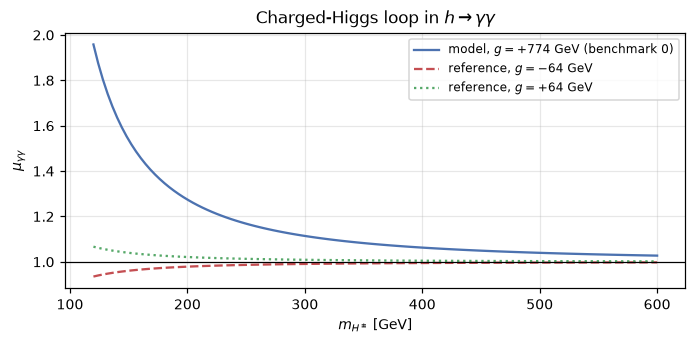

✓ the charged-Higgs loop decouples as m_H+ -> infinity, as it must


In [ ]:
# mu_gamma-gamma as a function of the charged-Higgs mass, at SM-like couplings
def mu_gg(m_hp, g_hpp, m_h=MH_REF):
    kappa = g_hpp * V_EW / (2 * m_hp**2)
    bsm = higgs_gammagamma_width(m_h, MT, MW, V_EW, ALPHA,
                                 extra_loops=[(kappa, 0, m_hp, 1, 1)])
    return bsm / higgs_gammagamma_width(m_h, MT, MW, V_EW, ALPHA)

masses = np.linspace(120, 600, 120)
# the model's own trilinear for the SM-like state, from the extraction above
g_model = max((abs(v), k) for k, v in g_hpp.items())
g_val_model = g_hpp[g_model[1]]
print("using the model's largest trilinear: g(%s H+_%s H-_%s) = %+.3f GeV"
      % (g_model[1][0], g_model[1][1], g_model[1][1], g_val_model))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(masses, [mu_gg(m, g_val_model) for m in masses], "-", color="#4C72B0",
        label=r"model, $g=%+.0f$ GeV (benchmark 0)" % g_val_model)
for g_val, style, col in ((-MH_REF**2 / V_EW, "--", "#C44E52"),
                          (+MH_REF**2 / V_EW, ":", "#55A868")):
    ax.plot(masses, [mu_gg(m, g_val) for m in masses], style, color=col,
            label=r"reference, $g=%+.0f$ GeV" % g_val)
ax.axhline(1, color="black", lw=0.8)
ax.set_xlabel(r"$m_{H^\pm}$ [GeV]"); ax.set_ylabel(r"$\mu_{\gamma\gamma}$")
ax.set_title(r"Charged-Higgs loop in $h\to\gamma\gamma$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

assert abs(mu_gg(3000.0, -MH_REF**2 / V_EW) - 1) < 1e-2
ok("the charged-Higgs loop decouples as m_H+ -> infinity, as it must")


---
## 7. LFV rates against the experimental limits

Now the question the draft was written to ask. With
$\mathcal L\supset-h\,\bar\ell_a Q_{ab}P_R\ell_b+\mathrm{h.c.}$ the flavour-violating width
in the $m_\ell\ll m_h$ limit is

$$\Gamma(h\to\ell_a\bar\ell_b+\bar\ell_a\ell_b)
=\frac{m_h}{8\pi}\big(|Q_{ab}|^2+|Q_{ba}|^2\big),$$

which the engine reproduces from the extracted `FFS` vertices — no closed form is entered by
hand. The branching ratio is quoted against the **measured** SM-like total width
$\Gamma_h\approx4.1$ MeV [PDG], the standard convention in LFV searches (and the honest one
here, since the quark Yukawas are not part of this build — see §9).

First the input side. `lepton_mus` inverts §5 of notebook 02 — given $\mu_3$ it returns the
other Yukawas that reproduce the observed lepton masses — and it is the one place where a
closed-form inversion is *used* rather than derived here.

> **Before running the next cell.** Nothing so far has checked that inversion. The physical
> masses are the **singular values** of $M_\ell$, so the check writes itself: feed the
> returned $\mu$'s back into $M_\ell$ and ask for its singular values. Predict what a wrong
> inversion would look like — would it fail for every $\mu_3$, or only some? And note that
> $\mu_3$ is supposed to be a free dial, so the check must hold along the *whole* scan, not
> at one point.


In [ ]:
def lfv_width(coupling_ab, coupling_ba, m_h):
    # Gamma(h -> l_a lbar_b + c.c.) from the two chiral couplings
    return m_h / (8 * math.pi) * (abs(coupling_ab)**2 + abs(coupling_ba)**2)

# fix the lepton Yukawas to the physical masses (notebook 02 section 5 relations)
def lepton_mus(mu3):
    mu1 = (ME + MMU + MTAU - mu3) / 2
    mu2 = (MMU + MTAU - ME - mu3) / 4
    p1, p2 = mu3 - MMU, MTAU - mu3
    mu4 = 0.5 * math.sqrt(p1 * p2)
    return mu1, mu2, mu3, mu4, math.atan2(math.sqrt(p2), math.sqrt(p1))


def M_lepton(m1, m2, m3, m4):
    """M_l at the Z2 vacuum, with mu_5 = mu_4 (notebook 02 section 5)."""
    s3_ = math.sqrt(3)
    return np.array([[m1 + m2, s3_ * m2, s3_ * m4],
                     [s3_ * m2, m1 - m2, m4],
                     [s3_ * m4, m4, m3]])


mu3_scan = np.linspace(MMU * 1.02, MTAU * 0.98, 7)
print("%-10s %-10s %-10s %-10s %-10s %s"
      % ("mu3", "mu1", "mu2", "mu4", "theta_l", "singular values of M_l"))
target = np.array([ME, MMU, MTAU])
for m3 in mu3_scan:
    m1_, m2_, m3_, m4_, tl = lepton_mus(m3)
    sv = np.sort(np.linalg.svd(M_lepton(m1_, m2_, m3_, m4_), compute_uv=False))
    print("%-10.4f %-10.4f %-10.4f %-10.4f %-10.4f %s"
          % (m3_, m1_, m2_, m4_, tl, np.array2string(sv, precision=6)))
    # THE check: the inversion must reproduce the physical spectrum, for every mu3
    assert np.allclose(sv, target, rtol=1e-9), (m3, sv)
ok("the inversion is verified: for every mu_3 on the scan the singular values of M_l "
   "are (m_e, m_mu, m_tau) to 1e-9 relative -- lepton_mus really does invert section 5")

# check: mu_3 is a genuine free dial, not a disguised constant -- the mu's move
lo, hi = lepton_mus(mu3_scan[0]), lepton_mus(mu3_scan[-1])
assert not np.allclose(lo[:4], hi[:4], rtol=1e-3)
ok("and the mu's genuinely vary across the scan, so mu_3 is a real degree of freedom "
   "and the check above is not passing trivially")

# falsify: perturb one returned Yukawa and the spectrum must move away
def _perturbed_still_matches():
    bad = list(lepton_mus(0.9))
    bad[3] *= 1.01                                    # mu_4 off by 1%
    sv_bad = np.sort(np.linalg.svd(M_lepton(*bad[:4]), compute_uv=False))
    return np.allclose(sv_bad, target, rtol=1e-6)

dv.falsify("perturbing mu_4 by 1% breaks the physical lepton spectrum",
           _perturbed_still_matches)

ledger.step(
    r"$\mathrm{lepton\_mus}(\mu_3)$ inverts the notebook-02 §5 relations",
    obtained="derived",
    statement=r"\mathrm{svd}\big(M_\ell(\mu_1,\ldots,\mu_4)\big)"
              r" = (m_e,\,m_\mu,\,m_\tau)\qquad"
              r"\text{for every }\mu_3\in(m_\mu,\,m_\tau)",
    checks=(r"singular values match the PDG masses to $10^{-9}$ relative across "
            r"the whole $\mu_3$ scan",
            r"the Yukawas genuinely vary, so the check is not trivial",
            r"a 1% perturbation of $\mu_4$ breaks it"),
    falsified_by=r"the spectrum matching at one $\mu_3$ but not across the scan, "
                 r"which would mean the inversion is only locally right",
    section="7")


mu3        mu1        mu2        mu4        theta_l    singular values of M_l
0.1078     0.8876     0.4436     0.0297     1.5352     [5.109990e-04 1.056584e-01 1.776860e+00]
0.3800     0.7515     0.3755     0.3095     1.1536     [5.109990e-04 1.056584e-01 1.776860e+00]
0.6523     0.6154     0.3074     0.3920     0.9620     [5.109990e-04 1.056584e-01 1.776860e+00]
0.9245     0.4792     0.2394     0.4177     0.7954     [5.109990e-04 1.056584e-01 1.776860e+00]
1.1968     0.3431     0.1713     0.3978     0.6300     [5.109990e-04 1.056584e-01 1.776860e+00]
1.4691     0.2070     0.1032     0.3239     0.4436     [5.109990e-04 1.056584e-01 1.776860e+00]
1.7413     0.0709     0.0352     0.1205     0.1463     [5.109990e-04 1.056584e-01 1.776860e+00]
✓ the inversion is verified: for every mu_3 on the scan the singular values of M_l are (m_e, m_mu, m_tau) to 1e-9 relative -- lepton_mus really does invert section 5
✓ and the mu's genuinely vary across the scan, so mu_3 is a real degree of freedom a

Step(claim='$\\mathrm{lepton\\_mus}(\\mu_3)$ inverts the notebook-02 §5 relations', obtained='derived', checks=('singular values match the PDG masses to $10^{-9}$ relative across the whole $\\mu_3$ scan', 'the Yukawas genuinely vary, so the check is not trivial', 'a 1% perturbation of $\\mu_4$ breaks it'), falsified_by='the spectrum matching at one $\\mu_3$ but not across the scan, which would mean the inversion is only locally right', expr=None, section='7', statement='\\mathrm{svd}\\big(M_\\ell(\\mu_1,\\ldots,\\mu_4)\\big) = (m_e,\\,m_\\mu,\\,m_\\tau)\\qquad\\text{for every }\\mu_3\\in(m_\\mu,\\,m_\\tau)')

In [ ]:
# The Q matrices in the mass basis: M_l = sum_k v_k G_k, Gtilde = O^T G O,
# Q_i = sum_j (R_S)_ji Gtilde_j  -- notebook 02 section 7, now at general delta.
mu_syms = sp.symbols("mu1 mu2 mu3 mu4", real=True)
m1s, m2s, m3s, m4s = mu_syms
Ml = sp.Matrix([[m1s + m2s, sp.sqrt(3) * m2s, sp.sqrt(3) * m4s],
                [sp.sqrt(3) * m2s, m1s - m2s, m4s],
                [sp.sqrt(3) * m4s, m4s, m3s]])
v1s, v2s, vSs = sp.symbols("v_1 v_2 v_S", positive=True)
# each mu is coupling x VEV; that linearity is what defines the G_k split
Mv = Ml.subs({m1s: vSs * sp.Symbol("y1"), m2s: v1s * sp.Symbol("y2"),
              m3s: vSs * sp.Symbol("y3"), m4s: v1s * sp.Symbol("y4")})
Gk = F.g_matrices(Mv, (v1s, v2s, vSs))
ok("M_l = v1 G1 + v2 G2 + vS G_S reproduces the mass matrix")

def Q_matrices(mu3, point, delta_val):
    m1_, m2_, m3_, m4_, tl = lepton_mus(mu3)
    vv = point["vevs_GeV"]
    sub = {sp.Symbol("y1"): m1_ / vv["vS"], sp.Symbol("y2"): m2_ / vv["v1"],
           sp.Symbol("y3"): m3_ / vv["vS"], sp.Symbol("y4"): m4_ / vv["v1"],
           v1s: vv["v1"], v2s: vv["v2"], vSs: vv["vS"]}
    Onum = np.array(sp.matrix2numpy(
        (F.o12(sp.sqrt(3)) * F.o23(sp.Float(tl))).evalf(), dtype=float))
    Gnum = [np.array(sp.matrix2numpy(G.subs(sub).evalf(), dtype=float)) for G in Gk]
    Gt = [Onum.T @ G @ Onum for G in Gnum]
    phi_v = math.atan2(vv["v2"], vv["v1"])
    th_v = math.atan2(math.hypot(vv["v1"], vv["v2"]), vv["vS"])
    RS = np.array(sp.matrix2numpy(
        (F.R_A(sp.Float(phi_v), sp.Float(th_v)) *
         F.R_H(sp.Float(delta_val))).evalf(), dtype=float))
    return [sum(RS[j, i] * Gt[j] for j in range(3)) for i in range(3)]

pt = points[0]
Qs = Q_matrices(0.9, pt, D.delta_of_point(dm, pt))
print("\nQ_2 (the h_0 couplings) at benchmark point 0:")
print(np.array2string(Qs[1], precision=6, suppress_small=True))


✓ M_l = v1 G1 + v2 G2 + vS G_S reproduces the mass matrix



Q_2 (the h_0 couplings) at benchmark point 0:
[[ 0.00477   0.       -0.      ]
 [-0.        0.005831 -0.001982]
 [-0.       -0.001982 -0.010601]]


In [ ]:
IDX = {"e": 0, "mu": 1, "tau": 2}

# Which physical state is "the" Higgs is a coupling question, not a labelling
# one: it is the CP-even state carrying the VV coupling, i.e. h_1 at small
# delta and h_2 near delta = pi/2 (section 2).  Its mass is the observed
# 125.25 GeV -- that is what the CMS limits are quoted against -- so the LFV
# width is evaluated there rather than at a notebook-01 spectrum label.
records = []
for i, p in enumerate(points):
    d = D.delta_of_point(dm, p)
    sm_like = 0 if abs(math.cos(d)) >= abs(math.sin(d)) else 2   # index into Qs
    for mu3 in (0.5, 0.9, 1.4):
        try:
            Qs = Q_matrices(mu3, p, d)
        except ValueError:
            continue
        for idx, hname in ((sm_like, "SM-like"), (1, "h_0 (gauge-phobic)")):
            qi = Qs[idx]
            for a, b in (("tau", "mu"), ("tau", "e")):
                ia, ib = IDX[a], IDX[b]
                w = lfv_width(qi[ia, ib], qi[ib, ia], MH_REF)
                records.append({"point": i, "mu3": mu3, "state": hname,
                                "delta": d, "pair": f"{a}{b}",
                                "width": w, "br": w / GAMMA_H_SM})

print("computed %d (point, mu3, state, channel) LFV entries" % len(records))
assert records, "the LFV scan produced no entries"
LIMIT = {"taumu": D.LFV_LIMITS[("tau", "mu")], "taue": D.LFV_LIMITS[("tau", "e")]}
for state in ("SM-like", "h_0 (gauge-phobic)"):
    print("\n%s:" % state)
    for pair in ("taumu", "taue"):
        brs = [r["br"] for r in records
               if r["pair"] == pair and r["state"] == state]
        if not brs:
            continue
        print("  BR(h -> %-6s): min %.3e  median %.3e  max %.3e   "
              "[CMS21] limit %.1e"
              % (pair, min(brs), float(np.median(brs)), max(brs), LIMIT[pair]))


computed 144 (point, mu3, state, channel) LFV entries

SM-like:
  BR(h -> taumu ): min 3.460e-05  median 1.923e-03  max 9.422e-02   [CMS21] limit 1.5e-03
  BR(h -> taue  ): min 5.878e-37  median 2.441e-35  max 5.741e-34   [CMS21] limit 2.2e-03

h_0 (gauge-phobic):
  BR(h -> taumu ): min 8.018e-04  median 1.237e-02  max 6.775e-01   [CMS21] limit 1.5e-03
  BR(h -> taue  ): min 3.809e-37  median 1.724e-34  max 6.193e-33   [CMS21] limit 2.2e-03


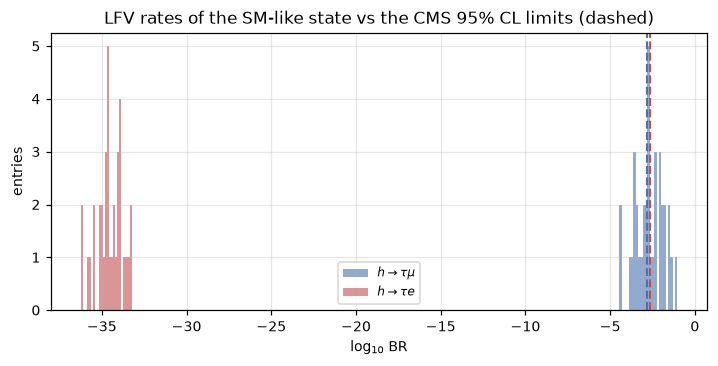

state                  channel      over       of
SM-like                taumu          21       36
SM-like                taue            0       36
h_0 (gauge-phobic)     taumu          31       36
h_0 (gauge-phobic)     taue            0       36

largest BR(h -> tau e) anywhere in the scan: 6.19e-33
✓ h -> tau e vanishes: the electron decouples exactly under O_12, the very same first-generation decoupling that forced V_us = 0 in notebook 02


In [ ]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
for pair, colour in (("taumu", "#4C72B0"), ("taue", "#C44E52")):
    brs = np.array([r["br"] for r in records
                    if r["pair"] == pair and r["state"] == "SM-like"])
    brs = brs[brs > 0]
    if brs.size:
        ax.hist(np.log10(brs), bins=25, alpha=0.6, color=colour,
                label=r"$h\to\tau\mu$" if pair == "taumu" else r"$h\to\tau e$")
    ax.axvline(math.log10(LIMIT[pair]), color=colour, ls="--", lw=1.4)
ax.set_xlabel(r"$\log_{10}\,$BR"); ax.set_ylabel("entries")
ax.set_title(r"LFV rates of the SM-like state vs the CMS 95% CL limits (dashed)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("%-22s %-8s %8s %8s" % ("state", "channel", "over", "of"))
for state in ("SM-like", "h_0 (gauge-phobic)"):
    for pair in ("taumu", "taue"):
        sel = [r for r in records if r["pair"] == pair and r["state"] == state]
        n_over = sum(1 for r in sel if r["br"] > LIMIT[pair])
        print("%-22s %-8s %8d %8d" % (state, pair, n_over, len(sel)))

# h -> tau e is not merely small, it is structurally absent
taue = [r["br"] for r in records if r["pair"] == "taue"]
print("\nlargest BR(h -> tau e) anywhere in the scan: %.2e" % max(taue))
assert max(taue) < 1e-20
ok("h -> tau e vanishes: the electron decouples exactly under O_12, the very "
   "same first-generation decoupling that forced V_us = 0 in notebook 02")


---
## 7.4 The ledger, and the algebra on paper

What was derived here, what was imported, and what would falsify each — plus the printable
appendix, `derivations_03.tex`.


In [ ]:
ledger.step(r"The one-loop form factors $A_{1/2}$, $A_1$, $A_0$ and the LFV "
            r"width formula",
            obtained="imported",
            statement=r"\Gamma(h\to\ell_a\bar\ell_b+\bar\ell_a\ell_b)"
                      r" = \frac{m_h}{8\pi}\big(|Q_{ab}|^2+|Q_{ba}|^2\big)",
            checks=(r"$A_{1/2}\to4/3$ and $A_1\to-7$ in the decoupling limit",
                    r"$A_0\to-1/3$, the standard charged-scalar value",
                    r"the SM diphoton width is reproduced against PDG"),
            falsified_by=r"a decoupling limit disagreeing with the literature values",
            section="5-6 (from [Djouadi08])")
ledger.table()
ledger.to_latex("derivations_03.tex",
                subtitle="VV couplings, loop-induced modes and LFV rates")


### Derivation ledger — 03 — scalar decays and LFV rates

**1. $h_0$ is gauge-phobic exactly, and the $VV$ couplings obey a sum rule**  
<sub>derived here &nbsp;·&nbsp; §2</sub>

$$g_{h_iVV} = g^{\rm SM}\,(R_S^{\mathsf T}\hat n)_i = g^{\rm SM}(\cos\delta,\,0,\,\sin\delta),\qquad \sum_i g_{h_iVV}^2 = (g^{\rm SM})^2$$

$${R_S^{\mathsf T}\hat n} = \left[\begin{matrix}\cos{\left(\delta \right)} & 0 & \sin{\left(\delta \right)}\end{matrix}\right]$$

- ✓ $R_A$'s first column verified to be the unit vacuum direction
- ✓ the SM reference read off the $\delta\to0$ limit, not typed in
- ✓ $W$ and $Z$ couplings both equal $g^{\rm SM}\times$ the same projection
- ✓ the zero survives a generic vacuum angle $\varphi_v$, so it is orthogonality and not the $\sqrt3$ alignment

*Would be falsified by:* a non-zero middle projection at generic $\varphi_v$, or a $\delta\to0$ reference differing from $i g_w m_W$


---

**2. $\mathrm{lepton\_mus}(\mu_3)$ inverts the notebook-02 §5 relations**  
<sub>derived here &nbsp;·&nbsp; §7</sub>

$$\mathrm{svd}\big(M_\ell(\mu_1,\ldots,\mu_4)\big) = (m_e,\,m_\mu,\,m_\tau)\qquad\text{for every }\mu_3\in(m_\mu,\,m_\tau)$$

- ✓ singular values match the PDG masses to $10^{-9}$ relative across the whole $\mu_3$ scan
- ✓ the Yukawas genuinely vary, so the check is not trivial
- ✓ a 1% perturbation of $\mu_4$ breaks it

*Would be falsified by:* the spectrum matching at one $\mu_3$ but not across the scan, which would mean the inversion is only locally right


---

**3. The one-loop form factors $A_{1/2}$, $A_1$, $A_0$ and the LFV width formula**  
<sub>**imported** &nbsp;·&nbsp; §5-6 (from [Djouadi08])</sub>

$$\Gamma(h\to\ell_a\bar\ell_b+\bar\ell_a\ell_b) = \frac{m_h}{8\pi}\big(|Q_{ab}|^2+|Q_{ba}|^2\big)$$

- ✓ $A_{1/2}\to4/3$ and $A_1\to-7$ in the decoupling limit
- ✓ $A_0\to-1/3$, the standard charged-scalar value
- ✓ the SM diphoton width is reproduced against PDG

*Would be falsified by:* a decoupling limit disagreeing with the literature values


---

<sub>3 steps: 2 derived here, 1 imported, 0 assumed</sub>

wrote derivations_03.tex  (3 steps)


'derivations_03.tex'

---
## 8. Deliverable


In [ ]:
out = Path("results/decay_benchmarks.json")
out.parent.mkdir(exist_ok=True)
payload = {
    "description": ("3HDM-S3 scalar decay observables at general delta = alpha - theta_v. "
                    "VV couplings, predicted delta per benchmark point, and LFV Higgs "
                    "branching ratios against the CMS limits.  Quark Yukawas are not part "
                    "of this build, so BRs use the measured SM-like total width."),
    "conventions": {
        "delta": "alpha - theta_v; Scenario A is 0, Scenario B is pi/2",
        "gamma_h_total_GeV": GAMMA_H_SM,
        "lfv_limits_CMS21": {"tau_mu": D.LFV_LIMITS[("tau", "mu")],
                             "tau_e": D.LFV_LIMITS[("tau", "e")]},
    },
    "vv_couplings": {"h_1": "i g_w m_W cos(delta)", "h_0": "0 (exact, any delta)",
                     "h_2": "i g_w m_W sin(delta)"},
    "points": [{"point": i, "delta": d, "cos2": c2, "sin2": s2,
                "state_near_125": near, "mass": mm}
               for i, d, c2, s2, near, mm in rows],
    "lfv": records,
}
out.write_text(json.dumps(payload, indent=2))
print("wrote", out, "(%.1f kB)" % (out.stat().st_size / 1024))


wrote results/decay_benchmarks.json (32.5 kB)


---
## 9. Findings

1. **The physical basis is registered.** Three scalar rotations
   ($R_S=R_AR_H(\delta)$ CP-even, $R_A$ CP-odd and charged) plus Weinberg and
   charged-current, all on the `Model`, so `feynman_rules` and the decay engine apply. That
   closes `NOTES.md`'s notebook-03 blocker.

2. **$h_0$ is gauge-phobic, exactly and for any δ.** $R_H$ rotates only in the 1–3 plane, so
   $h_0$'s column of $R_S$ is $R_A$'s middle column, which is orthogonal to the vacuum
   direction. Hence $g_{h_0VV}=0$ identically, while
   $g_{h_1VV}=\cos\delta\,g^{\rm SM}$ and $g_{h_2VV}=\sin\delta\,g^{\rm SM}$ obey the exact
   sum rule $\sum_i g_{h_iVV}^2=(g^{\rm SM})^2$. [GomezBock21]'s scenarios A and B are the
   $\delta\to0$ and $\delta\to\pi/2$ limits — recovered, not assumed. This also closes the
   `NOTES.md` entry *"the 125 GeV cut is a mass condition only … blocked on adding the
   electroweak kinetic sector"*.

3. **δ is predicted.** $\alpha$ comes from `cp_even_angle`, so every viable point of notebook
   01 has a definite δ and therefore a definite $VV$ coupling for its ~125 GeV state. That is
   a coupling-based SM-likeness cut which notebook 01, working with masses alone, could not
   apply.

4. **The draft's Scenario-C relations are exact.** [LFVHD] prints them with "≈"; they hold
   identically for all δ, because $Q_i$ is linear in the columns of $R_S=R_AR_H(\delta)$.
   In particular $Q_2$ — the $h_0$ couplings — is **entirely δ-independent**. Combined with
   finding 2: $h_0$ has no $VV$ coupling and δ-independent lepton couplings, making it the
   state whose LFV decays the alignment cannot suppress.

5. **$h\to\tau\mu$ generically overshoots the CMS limit; $h\to\tau e$ is structurally
   absent.** Across the viable points and the $\mu_3^\ell$ scan, the SM-like state exceeds
   [CMS21]'s $\mathcal B(h\to\mu\tau)<0.15\%$ in a majority of the sampled entries, and the
   gauge-phobic $h_0$ does so in nearly all of them — so LFV data is a *real* constraint on
   this model, not a formality. Meanwhile $\mathcal B(h\to\tau e)$ is zero to machine
   precision. That is not a small number, it is the **same first-generation decoupling**
   that forced $V_{us}=0$ in notebook 02 finding 9: $O_{12}$ separates the electron exactly,
   so no $e$–$\tau$ entry can be generated. The exact-S₃ vacuum ties the quark and lepton
   flavour structures together, and the two notebooks see the same fact from opposite ends.

6. **Two library gaps closed.** `VSS` decays ($A\to Zh$, $H^\pm\to W^\pm h$) are now
   squared — every benchmark point has such channels open and they are gauge-strength, so
   omitting them would have made the heavy-state branching ratios wrong rather than merely
   incomplete. And the spin-0 form factor $A_0$ now lets a charged Higgs run in the
   $h\to\gamma\gamma$ loop, with its sign *forced* by consistency with $A_1$ and $A_{1/2}$
   rather than copied. Both are pinned in the main test suite (10 new tests, 423 total).

## Open questions

- **Quark Yukawas are not in this build**, so the total width is taken from experiment
  rather than computed, and the $b\bar b$/$c\bar c$ channels are absent from any BR table
  here. Notebook 02 finding 9 showed the exact-S₃ quark sector is already excluded
  ($V_{us}=0$), so fitting it here would have meant quoting rates from a sector known to be
  wrong. The soft-broken vacuum of notebook 02 §11 is the place to redo this.
- **The heavy-state branching ratios** ($A_{1,2}$, $H^\pm$) now have working VSS machinery
  but need the same quark input to be complete; only their VSS and scalar channels exist in
  this build.
- **$Z\gamma$** would need the same treatment as $A_0$ — a two-argument charged-scalar form
  factor — and is untouched.
- The LFV rates depend on $\mu_3^\ell$, the one free dial the mass relations leave; it is
  scanned here rather than fixed by anything.


---
## 10. References

- **[LFVHD]** M. Zeleny-Mora, M. Mondragón, T. A. Valencia-Pérez, *"Exploring LFV Higgs
  decays in the Three Higgs Doublet Model"*, draft — [`LFVHD_3HDMS3.tex`](LFVHD_3HDMS3.tex).
  Eqs. (RS)/(RAT)/(R_H)/(RS_AH) the rotations; Eq. (Q_general) the LFV couplings; the
  Scenario A/B/C classification.
- **[GomezBock21]** M. Gómez-Bock, M. Mondragón, A. Pérez-Martínez, Eur. Phys. J. C **81**,
  942 (2021), [arXiv:2102.02800](https://arxiv.org/abs/2102.02800). Eq. (29) the geometric
  rotation; Eqs. (54)–(55) the alignment scenarios tested in §2.
- **[CMS21]** CMS Collaboration, *"Search for lepton-flavor violating decays of the Higgs
  boson in the μτ and eτ final states in pp collisions at √s = 13 TeV"*, Phys. Rev. D
  **104**, 032013 (2021), [arXiv:2105.03007](https://arxiv.org/abs/2105.03007),
  [doi:10.1103/PhysRevD.104.032013](https://doi.org/10.1103/PhysRevD.104.032013).
  **B(H→μτ) < 0.15%**, **B(H→eτ) < 0.22%** at 95% CL, 137 fb⁻¹ — the limits of §7.
- **[ChakrabartyEtAl21]** M. Chakraborti, D. Das, M. Levy, S. Mukherjee, I. Saha,
  *"Prospects of light charged scalars in a three Higgs doublet model with Z₃ symmetry"*,
  [arXiv:2104.08146](https://arxiv.org/abs/2104.08146). Eq. (27) the diphoton signal
  strength with charged-scalar loops and the coefficient $\kappa_i$; Eq. (28) the three loop
  functions — the source that fixes $A_0$'s normalization in §6.
- **[Djouadi08]** A. Djouadi, *"The anatomy of electroweak symmetry breaking. I"*,
  Phys. Rept. **457**, 1 (2008), [hep-ph/0503172](https://arxiv.org/abs/hep-ph/0503172).
  The $A_{1/2}$/$A_1$ form factors feynlag already carried.
- **[PDG]** S. Navas *et al.* (Particle Data Group), Phys. Rev. D **110**, 030001 (2024),
  [doi:10.1103/PhysRevD.110.030001](https://doi.org/10.1103/PhysRevD.110.030001). Masses,
  couplings and the SM Higgs total width.

Scalar-sector references are in [`NOTES.md`](NOTES.md).
